# UHI Classification: A Unified Pipeline

**Objective.** Classify Urban Heat Island intensity (High / Medium / Low) at 100 m resolution across Santiago (Chile), Rio de Janeiro (Brazil), and Freetown (Sierra Leone) using multispectral satellite imagery. Chile and Brazil have ground-truth labels; Sierra Leone is predicted via cross-city transfer.

**Approach.** 

**Part 1** — Brazil within-city: full features (spectral indices, elevation, OSM building metrics, interactions), RF vs XGB, ablation. 

**Part 2** — Chile within-city @ 100 m: engineered interactions + Quantile RF. 

**Part 3** — Sierra Leone: five-band `SPEC` only, independent quantile transforms, PCA(3), LOCO diagnostics, KMeans pseudo-labels for comparison, source-specialist OVR (RF + XGB), prevalence calibration, CSV export.

**Key results (benchmarks from the study; re-run cells for your run’s F1).** 

Brazil XGB often reaches F1 ≈ 0.96; Chile RF ≈ 0.69 (Medium class ambiguity). The specialist pipeline routes High → Brazil, Medium → Chile, Low → combined training data; blind tests matter more than pseudo-label metrics when choosing routing.

| Part | City / target | Role in this notebook |
|------|----------------|------------------------|
| **1** | Rio de Janeiro | Within-city model; merged `dataset_100m` + `buildings_*`. |
| **2** | Santiago | Within-city Quantile RF @ 100 m. |
| **3** | Freetown | Transfer: QT → PCA → specialists → calibration → `sierra_leone_submission.csv`. |

**Written report.** The next section condenses (introduction, three questions, pipeline narrative, feedback, references) so the notebook and the report stay aligned.


## Written report — concise summary

### Introduction (challenge framing)

The **Urban Heat Island (UHI) challenge** is to understand and predict how heat is distributed in cities using data and ML. UHI appears where built areas are warmer than surroundings (dense infrastructure, limited vegetation, heat-absorbing materials). **Labelled** grids come from **Santiago** and **Rio**; **Freetown** is predicted without local class labels. Inputs combine **ground-relevant information**, **satellite imagery**, and **geospatial** cues (vegetation, built-up, elevation). Accurate UHI mapping supports **health risk reduction** and **climate-resilient planning**.

Background overview (literature): [PMC — urban heat / planning context](https://pmc.ncbi.nlm.nih.gov/articles/PMC12470186/)

### 1) Which factor contributes most? (practical, non-technical)

There is **no single global answer** — drivers differ by city. **Santiago:** **elevation and surface temperature** stand out: the city sits in a **basin** surrounded by mountains, so topography and density trap heat and limit ventilation; lower, denser districts stay warmer (inversion/smog dynamics). **Rio:** **sunlight on urban surfaces** matters more than elevation: strong tropical insolation heats concrete and asphalt; dense, low-shade neighbourhoods accumulate heat during the day. In short: Santiago’s story is **basin topography + density**; Rio’s is **intense sun + surface materials**.

### 2) Mitigation beyond adding green space

Common levers across cities: **cool / reflective roofs**, **reflective or lighter materials**, **street and block layout** to improve **ventilation**, **shade** in busy public spaces, and **small water-based cooling** (misting, fountains) where appropriate. **Freetown:** prioritize **low-cost, scalable** actions (e.g. cooler roofing, white coatings, simple canopies) given informal growth and limited formal regulation of spacing/materials. **Rio:** emphasize **reflective pavements**, reducing **waste heat** from transport and buildings, and cooling **highly impervious** cores. **Santiago:** similar physical measures, often easier to implement through **formal planning**, retrofit rules, and material standards.

Further links from the report: [ScienceDirect](https://www.sciencedirect.com/science/article/abs/pii/S0303243417301770), [NASA — Climate proofing Rio](https://science.nasa.gov/earth/earth-observatory/climate-proofing-rio-de-janeiro-90687/)

### 3) Additional public data (if time were unlimited)

Useful **existing/open** layers include: **weather and microclimate** (e.g. **wind** speed/direction to explain trapping vs dispersion), **solar radiation**, **hourly or seasonal temperature series** (current labels are largely **snapshot**-like), finer **3D building / street-canyon** morphology, and **neighbourhood socioeconomic or population density** where published. Standardizing **time-of-day** and **repeat visits** for ground truth would reduce **temporal noise** in labels.


In [8]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

OUTPUT_DIR = os.environ.get('UHI_OUTPUT_DIR', '.')
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Data extraction (sensors & grids)

The dataset fuses three satellite sources resampled to a common **100 m** grid: **Sentinel-2 L2A** (13 optical bands, 10–60 m native), **Landsat 8/9** (visible + thermal at 30–100 m), and **Copernicus DEM** (30 m elevation). For each sample point the upstream pipeline used a **5×5 pixel neighborhood median** to smooth fine-scale noise while preserving local thermal signal. Sentinel-2 cloud masking uses the **Scene Classification Layer (SCL)** to reject clouds, shadows, cirrus, and saturated pixels before a temporal median composite — yielding dense coverage across study areas. **The building density** is computed from the 3D-GloBFP global building footprint shapefiles downloaded as grid tiles from Zenodo.

**Landsat thermal.** Early single-scene thermal without QA can produce invalid LST (e.g. heavy cloud cover). The production fix uses **QA_PIXEL** bit masking (cloud, shadow, snow, fill) and **composites across scenes**. Thermal composites represent **typical** surface temperature rather than one snapshot — slightly blurring the UHI signal but removing cloud contamination.


## Shared: data from GitHub & utilities

We load public CSVs from **Mickias-Ambaye / uhi-pipe** (`raw.githubusercontent.com`). `dataset_100m_*` holds grid features + labels; `buildings_*` adds OSM morphology columns merged onto the grid in **Part 1** (Brazil). Helpers below are used in multiple parts.


In [9]:
BASE = "https://raw.githubusercontent.com/Mickias-Ambaye/uhi-pipe/main/Dataset"

URLS_GRID = {
    "Chile": f"{BASE}/dataset_100m_Chile.csv",
    "Brazil": f"{BASE}/dataset_100m_Brazil.csv",
    "Sierra_Leone": f"{BASE}/dataset_100m_Sierra_Leone.csv",
}
URLS_BLDG = {
    "Chile": f"{BASE}/buildings_Chile.csv",
    "Brazil": f"{BASE}/buildings_Brazil.csv",
}

dfs = {}
for name in ["Chile", "Brazil", "Sierra_Leone"]:
    dfs[name] = pd.read_csv(URLS_GRID[name])
    print(f"{name} (100m grid): {len(dfs[name]):,} rows, {dfs[name].shape[1]} cols")

bldg_dfs = {}
for name in ["Chile", "Brazil"]:
    bldg_dfs[name] = pd.read_csv(URLS_BLDG[name])
    print(f"{name} (buildings): {len(bldg_dfs[name]):,} rows, {bldg_dfs[name].shape[1]} cols")

le = LabelEncoder()
le.fit(["High", "Low", "Medium"])

SPEC = ['lwir11', 'LST', 'SWIR2_NIR', 'blue', 'nir08']
RAW = ['LST', 'NDVI', 'NDBI', 'emissivity', 'NDVI_Landsat', 'elevation']


Chile (100m grid): 21,662 rows, 43 cols
Brazil (100m grid): 28,488 rows, 43 cols
Sierra_Leone (100m grid): 14,105 rows, 43 cols
Chile (buildings): 21,662 rows, 58 cols
Brazil (buildings): 28,488 rows, 58 cols


In [10]:
def merge_grid_and_buildings(grid, bldg, keys=('Latitude', 'Longitude')):
    """Attach building-only columns to the 100 m grid on lat/lon."""
    ks = list(keys)
    extra = [c for c in bldg.columns if c not in grid.columns]
    if not extra:
        return grid.copy()
    return grid.merge(bldg[ks + extra], on=ks, how='left')

def results_summary(model, X_train, X_test, y_train, y_test, le, model_name='Model'):
    """Train/test metrics, gap, classification report, confusion matrix."""
    y_tr_enc = le.transform(y_train) if y_train.dtype == object else y_train
    y_te_enc = le.transform(y_test) if y_test.dtype == object else y_test
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    f1_train = f1_score(y_tr_enc, pred_train, average='weighted')
    f1_test = f1_score(y_te_enc, pred_test, average='weighted')
    f1_gap = f1_train - f1_test
    acc_test = accuracy_score(y_te_enc, pred_test)
    prec_test = precision_score(y_te_enc, pred_test, average='weighted')
    rec_test = recall_score(y_te_enc, pred_test, average='weighted')
    auc = np.nan
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)
        if proba.shape[1] == len(le.classes_):
            auc = roc_auc_score(y_te_enc, proba, multi_class='ovr', average='weighted')
    print(f"{'='*60}")
    print(f"  {model_name} — Results Summary")
    print(f"{'='*60}")
    print(f"  F1 Train:     {f1_train:.4f}")
    print(f"  F1 Test:      {f1_test:.4f}")
    print(f"  F1 Gap:       {f1_gap:.4f}  {'⚠ HIGH' if abs(f1_gap) > 0.05 else '✓ stable'}")
    print(f"  Accuracy:     {acc_test:.4f}")
    print(f"  Precision:    {prec_test:.4f}")
    print(f"  Recall:       {rec_test:.4f}")
    print(f"  AUC (wt):     {auc:.4f}" if not np.isnan(auc) else '  AUC:          N/A')
    print('\nClassification Report:')
    print(classification_report(y_te_enc, pred_test, target_names=le.classes_))
    print('Confusion Matrix:')
    print(pd.DataFrame(confusion_matrix(y_te_enc, pred_test),
                       index=[f'True_{c}' for c in le.classes_],
                       columns=[f'Pred_{c}' for c in le.classes_]))
    return {'model': model_name, 'f1_train': f1_train, 'f1_test': f1_test,
            'f1_gap': f1_gap, 'accuracy': acc_test, 'precision': prec_test,
            'recall': rec_test, 'auc': auc}

def engineer_features(df):
    """Six interaction terms + drop redundant NDVI_Landsat."""
    df = df.copy()
    df["LST_x_NDVI"] = df["LST"] * df["NDVI"]
    df["LST_x_NDBI"] = df["LST"] * df["NDBI"]
    df["elev_x_LST"] = df["elevation"] * df["LST"]
    df["NDVI_minus_NDBI"] = df["NDVI"] - df["NDBI"]
    df["LST_x_Albedo"] = df["LST"] * df["Albedo"]
    df["BU_x_LST"] = df["BU"] * df["LST"]
    if "NDVI_Landsat" in df.columns:
        df.drop(columns=["NDVI_Landsat"], inplace=True)
    return df

def prepare_xy(df):
    """Model matrix + labels for Chile-style models."""
    df = engineer_features(df)
    drop_cols = [c for c in ["Latitude","Longitude","UHI_Class","label","resolution_m"] if c in df.columns]
    y = df["UHI_Class"] if "UHI_Class" in df.columns else None
    X = df.drop(columns=drop_cols)
    X = X.fillna(X.median()).replace([np.inf, -np.inf], np.nan).fillna(0)
    return X, y

def qt_pca_transform(X_tr_raw, X_te_raw, n_pca=3):
    """Independent QT per domain; PCA fit on train only (Part 3)."""
    qt_tr = QuantileTransformer(n_quantiles=min(1000, len(X_tr_raw)),
                                output_distribution='uniform', random_state=42)
    qt_te = QuantileTransformer(n_quantiles=min(1000, len(X_te_raw)),
                                output_distribution='uniform', random_state=42)
    X_tr = qt_tr.fit_transform(X_tr_raw)
    X_te = qt_te.fit_transform(X_te_raw)
    if n_pca and n_pca < X_tr.shape[1]:
        pca = PCA(n_components=n_pca, random_state=42)
        X_tr = pca.fit_transform(X_tr)
        X_te = pca.transform(X_te)
    else:
        pca = None
    return X_tr, X_te, pca


## How code maps to the report (“Key components of analysis”)

| Report theme | Realization in this notebook |
|--------------|-------------------------------|
| Integrate Sentinel-2, Landsat-class thermal, DEM features | Encoded in **`dataset_100m_*`** / **`buildings_*`** CSVs (upstream pipeline); we **load from GitHub** in the shared cell. |
| Feature engineering (NDVI, NDBI, LST, …) | **Part 1** full grid + buildings; **Part 2** Chile interactions; **Part 3** restricts to **`SPEC`** (five bands) for transfer. |
| Cloud masking, median compositing, neighbourhood (5×5) aggregation | Described under **Data extraction**; reflected in clean, analysis-ready tables. |
| Align rows geographically | **Brazil:** `merge_grid_and_buildings` on **Latitude / Longitude**. |
| City-specific scales → comparable modelling | **QuantileTransformer** within parts; **independent QT + PCA(3)** in Part 3. |
| Baseline RF → stronger tree model | **RF** and **XGBoost** in Part 1; **Quantile RF** in Part 2; **RF / XGB specialists** in Part 3. |
| Generalize across cities | **LOCO-style** Chile↔Brazil checks; **source-specialist OVR** + **calibration** for Sierra Leone. |


---
## Part 1 — Brazil: within-city classification

Rio’s labelled grid is **skewed toward High UHI** in many samples, reflecting dense tropical urban core. With **no train/test domain gap**, we use the **full feature set**: spectral indices, elevation, OSM building metrics where present, and **engineered interactions**. **Class imbalance** matters — tree models need balancing (RF `class_weight`, XGB `sample_weight`) so they do not collapse to the majority class.

### Preprocessing strategy (within-city)

Where train and test share the same city distribution, we use **QuantileTransformer (uniform)** on the full feature matrix so all inputs map to **[0, 1]** before RF/XGB. More features add signal because there is **no cross-city leakage** to suppress.

**Pipeline here:** merge grid + buildings → define feature groups → EDA → add interactions → 5-fold stratified CV (RF vs XGB) → best-model importance → ablation (spectral / +indices / full) → refit on all pixels → save CSV.


In [11]:
df = merge_grid_and_buildings(dfs['Brazil'].copy(), bldg_dfs['Brazil'])
print(f'Brazil merged: {len(df):,} rows × {df.shape[1]} cols')
print(df["UHI_Class"].value_counts())


Brazil merged: 28,488 rows × 58 cols
UHI_Class
High      12748
Low       10591
Medium     5149
Name: count, dtype: int64


### Feature groups

Exclude **Latitude / Longitude** from predictors. Spectral core, indices, `BUILDING` metrics (if present), `elevation`, then add interaction terms.


In [13]:
SPECTRAL = ['lwir11', 'LST', 'SWIR2_NIR', 'blue', 'nir08']
INDICES = ['NDVI', 'NDBI', 'BSI', 'NDWI', 'Albedo', 'EVI', 'emissivity',
           'SAVI', 'MNDWI', 'NDMI', 'ISA', 'BU', 'NDVI_Landsat']
BUILDING = ['building_density_100m', 'building_coverage_ratio', 'bldg_mean_height',
            'bldg_height_std', 'volume_density', 'bldg_count_100m', 'bldg_total_area',
            'bldg_total_volume', 'bldg_max_height', 'bldg_height_range',
            'mean_bldg_volume', 'bldg_height_max_ratio', 'sky_view_proxy',
            'open_space_ratio', 'compactness']
OTHER = ['elevation']
all_candidates = SPECTRAL + INDICES + BUILDING + OTHER
FEATURES = [c for c in all_candidates if c in df.columns]
print(f'Features available: {len(FEATURES)}')


Features available: 34


### EDA: distributions and correlations


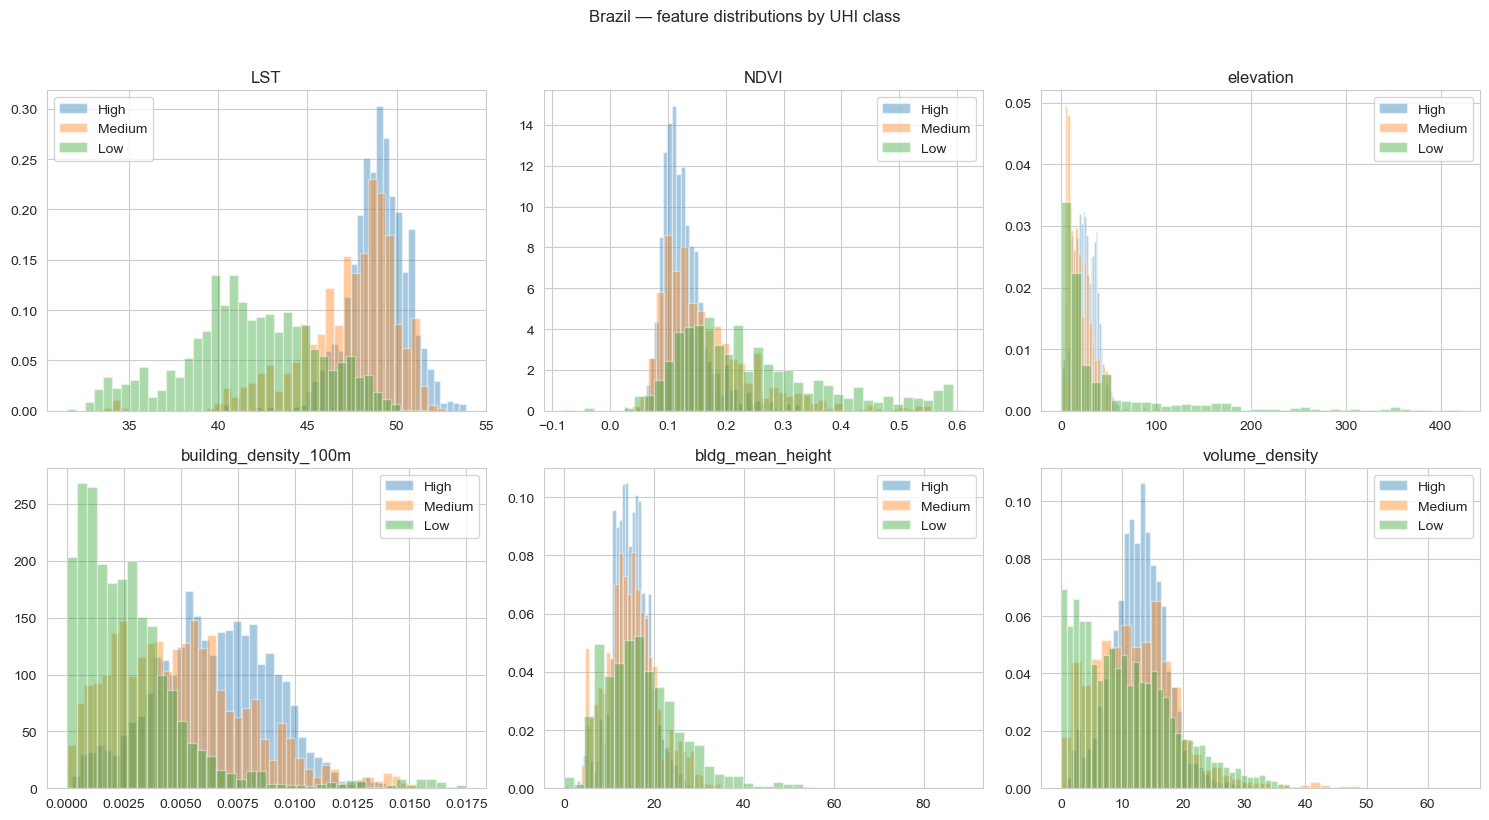

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes[0], ['LST', 'NDVI', 'elevation']):
    if feat not in df.columns:
        ax.axis('off'); continue
    for cls in ['High', 'Medium', 'Low']:
        vals = df[df['UHI_Class'] == cls][feat].dropna()
        ax.hist(vals, bins=40, alpha=0.4, label=cls, density=True)
    ax.set_title(feat); ax.legend()
bldg_feats = [f for f in ['building_density_100m', 'bldg_mean_height', 'volume_density'] if f in df.columns]
for ax, feat in zip(axes[1], bldg_feats + ['']*(3-len(bldg_feats))):
    if not feat: ax.axis('off'); continue
    for cls in ['High', 'Medium', 'Low']:
        vals = df[df['UHI_Class'] == cls][feat].dropna()
        ax.hist(vals, bins=40, alpha=0.4, label=cls, density=True)
    ax.set_title(feat); ax.legend()
plt.suptitle('Brazil — feature distributions by UHI class', y=1.02)
plt.tight_layout(); plt.show()


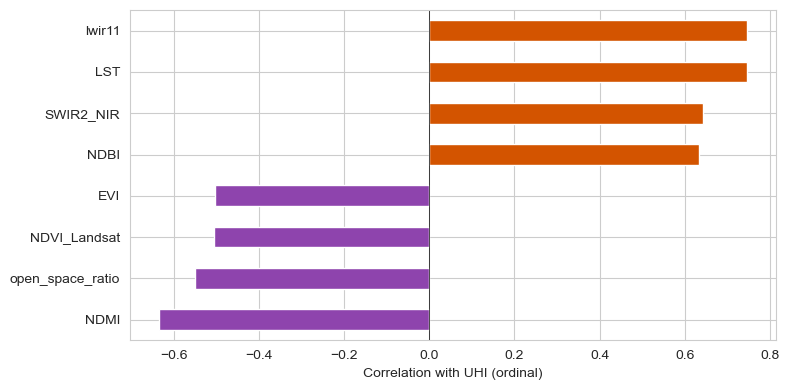

Most Correlated Feature Pairs:


building_density_100m    bldg_count_100m            1.000000
bldg_total_volume        volume_density             1.000000
open_space_ratio         building_coverage_ratio   -1.000000
NDMI                     NDBI                      -1.000000
NDVI                     SAVI                       1.000000
open_space_ratio         bldg_total_area           -0.999353
building_coverage_ratio  bldg_total_area            0.999353
lwir11                   LST                        0.997170
SAVI                     EVI                        0.992682
EVI                      NDVI                       0.992681
dtype: float64

In [18]:
class_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_ord = df['UHI_Class'].map(class_map)
corrs = df[FEATURES].corrwith(y_ord).sort_values(ascending=False)
top_bottom = pd.concat([corrs.head(4), corrs.tail(4)])
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d35400' if v > 0 else '#8e44ad' for v in top_bottom.values]
top_bottom.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with UHI (ordinal)')
ax.axvline(0, color='black', linewidth=0.5); ax.invert_yaxis()
plt.tight_layout(); plt.show()

corr = df[FEATURES].corr()
corr_pairs = corr.unstack().sort_values(key=abs, ascending=False)
corr_pairs = corr_pairs[corr_pairs != 1.0]
corr_pairs = corr_pairs[::2]
top_pairs = corr_pairs[abs(corr_pairs) > 0.6]
print("Most Correlated Feature Pairs:")
top_pairs.head(10)


### Interactions, CV, best model, ablation


In [19]:
if 'NDVI' in df.columns and 'LST' in df.columns:
    df['LST_x_NDVI'] = df['LST'] * df['NDVI']; FEATURES.append('LST_x_NDVI')
if 'NDBI' in df.columns and 'LST' in df.columns:
    df['LST_x_NDBI'] = df['LST'] * df['NDBI']; FEATURES.append('LST_x_NDBI')
if 'elevation' in df.columns and 'LST' in df.columns:
    df['elev_x_LST'] = df['elevation'] * df['LST']; FEATURES.append('elev_x_LST')
if 'NDVI' in df.columns and 'NDBI' in df.columns:
    df['NDVI_minus_NDBI'] = df['NDVI'] - df['NDBI']; FEATURES.append('NDVI_minus_NDBI')
if 'building_density_100m' in df.columns and 'LST' in df.columns:
    df['bldg_density_x_LST'] = df['building_density_100m'] * df['LST']; FEATURES.append('bldg_density_x_LST')
FEATURES = list(dict.fromkeys(FEATURES))
print('Total features:', len(FEATURES))

x = df[FEATURES].values
y_br = le.transform(df['UHI_Class'])
qt_br = QuantileTransformer(n_quantiles=min(1000, len(x)), output_distribution='uniform', random_state=42)
x = qt_br.fit_transform(x)

models = {
    'RF': RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB': XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1,
        random_state=42, n_jobs=-1, eval_metric='mlogloss', verbosity=0),
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []; fold_details = {name: [] for name in models}
for name, model in models.items():
    for fold, (tr_idx, te_idx) in enumerate(skf.split(x, y_br)):
        x_tr, x_te = x[tr_idx], x[te_idx]
        y_tr, y_te = y_br[tr_idx], y_br[te_idx]
        if name == 'XGB':
            sw = compute_sample_weight('balanced', y_tr)
            model.fit(x_tr, y_tr, sample_weight=sw)
        else:
            model.fit(x_tr, y_tr)
        f1_tr = f1_score(y_tr, model.predict(x_tr), average='weighted')
        y_pred = model.predict(x_te)
        f1_te = f1_score(y_te, y_pred, average='weighted')
        per_class = {}
        for cls_name in ['High', 'Medium', 'Low']:
            cls_idx = le.transform([cls_name])[0]
            mask_te = (y_te == cls_idx); mask_pred = (y_pred == cls_idx)
            tp = (mask_te & mask_pred).sum()
            prec = tp / max(mask_pred.sum(), 1); rec = tp / max(mask_te.sum(), 1)
            per_class[cls_name] = 2 * prec * rec / max(prec + rec, 1e-9)
        print(f'{name} fold{fold} F1_train={f1_tr:.3f} F1_test={f1_te:.3f} gap={f1_tr-f1_te:.3f}')
        results.append({'model': name, 'fold': fold, 'f1_train': f1_tr, 'f1_test': f1_te,
                        'gap': f1_tr - f1_te, **per_class})
        fold_details[name].append({'y_true': y_te, 'y_pred': y_pred})
df_results = pd.DataFrame(results)
summary = df_results.groupby('model').agg({'f1_train': 'mean', 'f1_test': 'mean', 'gap': 'mean',
    'High': 'mean', 'Medium': 'mean', 'Low': 'mean'}).round(3)
print('\n=== Brazil CV summary ===')
print(summary.to_string())


Total features: 39
RF fold0 F1_train=0.966 F1_test=0.947 gap=0.020
RF fold1 F1_train=0.968 F1_test=0.945 gap=0.022
RF fold2 F1_train=0.967 F1_test=0.947 gap=0.021
RF fold3 F1_train=0.967 F1_test=0.948 gap=0.019
RF fold4 F1_train=0.968 F1_test=0.949 gap=0.020
XGB fold0 F1_train=0.998 F1_test=0.961 gap=0.037
XGB fold1 F1_train=0.998 F1_test=0.959 gap=0.039
XGB fold2 F1_train=0.998 F1_test=0.957 gap=0.040
XGB fold3 F1_train=0.998 F1_test=0.961 gap=0.037
XGB fold4 F1_train=0.999 F1_test=0.959 gap=0.040

=== Brazil CV summary ===
       f1_train  f1_test    gap   High  Medium    Low
model                                                
RF        0.967    0.947  0.020  0.959   0.865  0.972
XGB       0.998    0.959  0.039  0.969   0.889  0.982


Best: XGB mean test F1=0.959


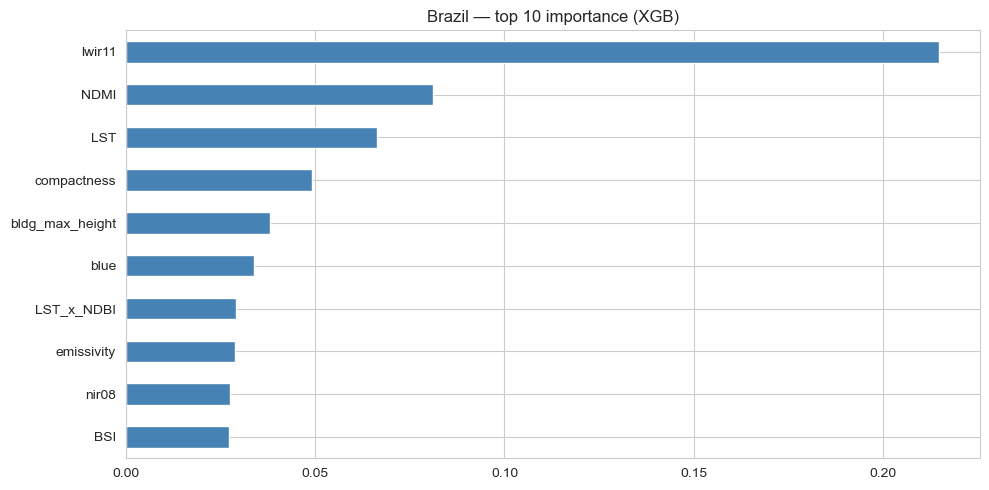

In [20]:
best_model_name = summary['f1_test'].idxmax()
print(f'Best: {best_model_name} mean test F1={summary.loc[best_model_name, "f1_test"]:.3f}')
best_model = models[best_model_name]
sw_full = compute_sample_weight('balanced', y_br)
if best_model_name == 'XGB':
    best_model.fit(x, y_br, sample_weight=sw_full)
else:
    best_model.fit(x, y_br)
imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Brazil — top 10 importance ({best_model_name})')
plt.tight_layout(); plt.show()


### Brazil — interpretation (typical findings)

In the original study, **XGBoost with sample-weight balancing** often edged out RF on weighted F1, with **thermal bands and interactions** (e.g. LST×NDVI, LST×NDBI) at the top of importance, and **elevation** secondary in coastal Rio where topography varies modestly. **Your** CV summary and importance plot above are the authoritative numbers for this run — use them to confirm the same pattern.


Spectral only (5): F1=0.933 ± 0.003
Spectral + Indices: F1=0.936 ± 0.002
Full: F1=0.947 ± 0.001


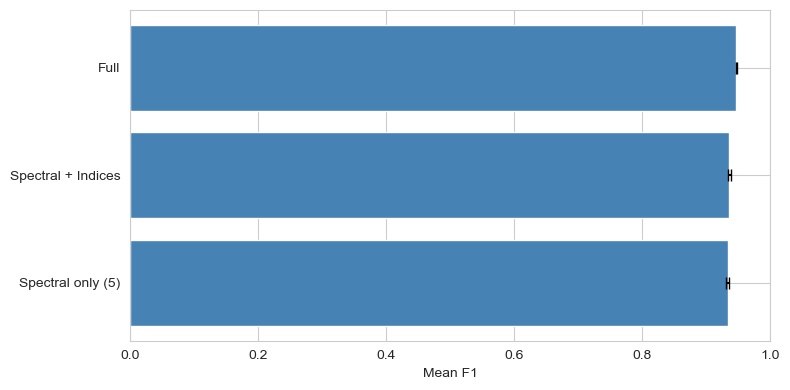

In [21]:
feature_sets = {
    'Spectral only (5)': [f for f in SPECTRAL if f in df.columns],
    'Spectral + Indices': [f for f in SPECTRAL + INDICES if f in df.columns],
    'Full': FEATURES,
}
ablation = []
for fs_name, feats in feature_sets.items():
    x_raw = df[feats].fillna(0).values
    qt_fs = QuantileTransformer(n_quantiles=min(1000, len(x_raw)), output_distribution='uniform', random_state=42)
    x_fs = qt_fs.fit_transform(x_raw)
    y_fs = le.transform(df['UHI_Class'])
    fold_f1s = []
    for tr_idx, te_idx in skf.split(x_fs, y_fs):
        rf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=5,
            class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(x_fs[tr_idx], y_fs[tr_idx])
        fold_f1s.append(f1_score(y_fs[te_idx], rf.predict(x_fs[te_idx]), average='weighted'))
    ablation.append({'features': fs_name, 'n_features': len(feats), 'mean_f1': np.mean(fold_f1s), 'std_f1': np.std(fold_f1s)})
    print(f'{fs_name}: F1={np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}')
df_ablation = pd.DataFrame(ablation)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_ablation['features'], df_ablation['mean_f1'], xerr=df_ablation['std_f1'], color='steelblue', capsize=4)
ax.set_xlabel('Mean F1'); ax.set_xlim(0, 1); plt.tight_layout(); plt.show()


In [22]:
final_model = models[best_model_name]
if best_model_name == 'XGB':
    final_model.fit(x, y_br, sample_weight=sw_full)
else:
    final_model.fit(x, y_br)
y_pred_full = final_model.predict(x)
print('Brazil full-sample weighted F1:', f1_score(y_br, y_pred_full, average='weighted'))
df_out = df[['Longitude', 'Latitude', 'UHI_Class']].copy()
df_out['predicted'] = le.inverse_transform(y_pred_full)
df_out['correct'] = df_out['UHI_Class'] == df_out['predicted']
print('Accuracy:', df_out['correct'].mean())
br_path = os.path.join(OUTPUT_DIR, 'brazil_within_city_predictions.csv')
df_out.to_csv(br_path, index=False)
print('Saved', br_path)


Brazil full-sample weighted F1: 0.9969550468774468
Accuracy: 0.9969460825610783
Saved ./brazil_within_city_predictions.csv


---
## Part 2 — Chile: within-city model @ 100 m

Santiago differs from Rio: the **Medium** class is often **~50%** of pixels and **spectrally overlaps** High and Low. **Topography** (wide elevation range) is a dominant cue — **elevation** and **elev×LST** can drive a large share of importance. That is a **transferability caveat** for Freetown (coastal, flat): **Part 3** therefore uses only the **five spectral bands**, not elevation-heavy engineered stacks.

**Pipeline here:** filter Chile labelled rows → EDA (class balance, LST–NDVI, interaction boxplots) → `prepare_xy` + QuantileTransformer + **regularized RandomForest** (deep cap, min split, optional pruning via `ccp_alpha`) → train/test report + importance plot.


### Chile data slice & EDA


In [23]:
train_test_100 = dfs['Chile'].dropna(subset=['UHI_Class']).copy()
if 'label' in train_test_100.columns:
    train_test_100 = train_test_100[train_test_100['label'] == 'Chile'].copy()
print(f'Chile training rows: {len(train_test_100)}')
print(train_test_100['UHI_Class'].value_counts())

def prepare_eda_data(df):
    df = engineer_features(df.copy())
    drop_cols = ["Latitude", "Longitude", "label", "resolution_m"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    return df.fillna(df.median(numeric_only=True)).replace([np.inf, -np.inf], np.nan).fillna(0)

df_viz = prepare_eda_data(train_test_100)
class_order = ['Low', 'Medium', 'High']
class_colors = {'Low': '#3498db', 'Medium': '#f1c40f', 'High': '#e74c3c'}


Chile training rows: 21662
UHI_Class
Medium    10816
Low        5529
High       5317
Name: count, dtype: int64


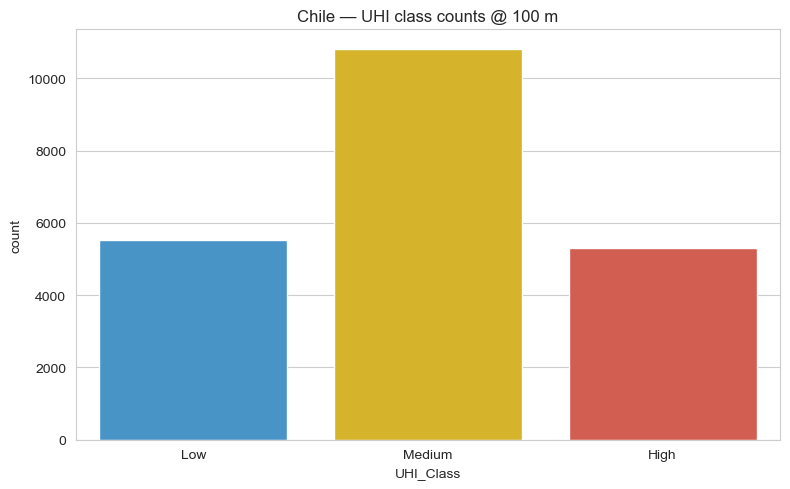

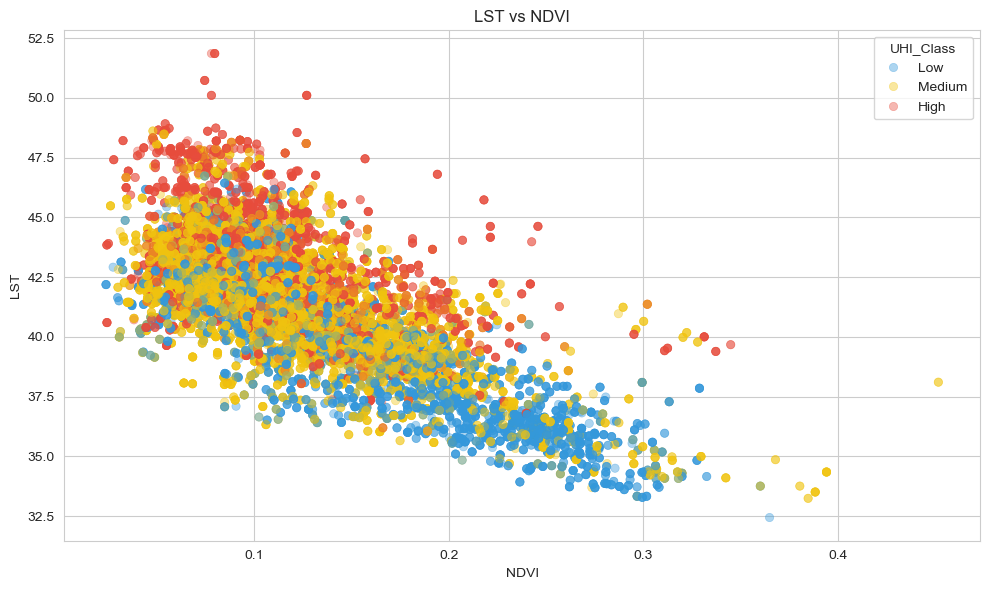

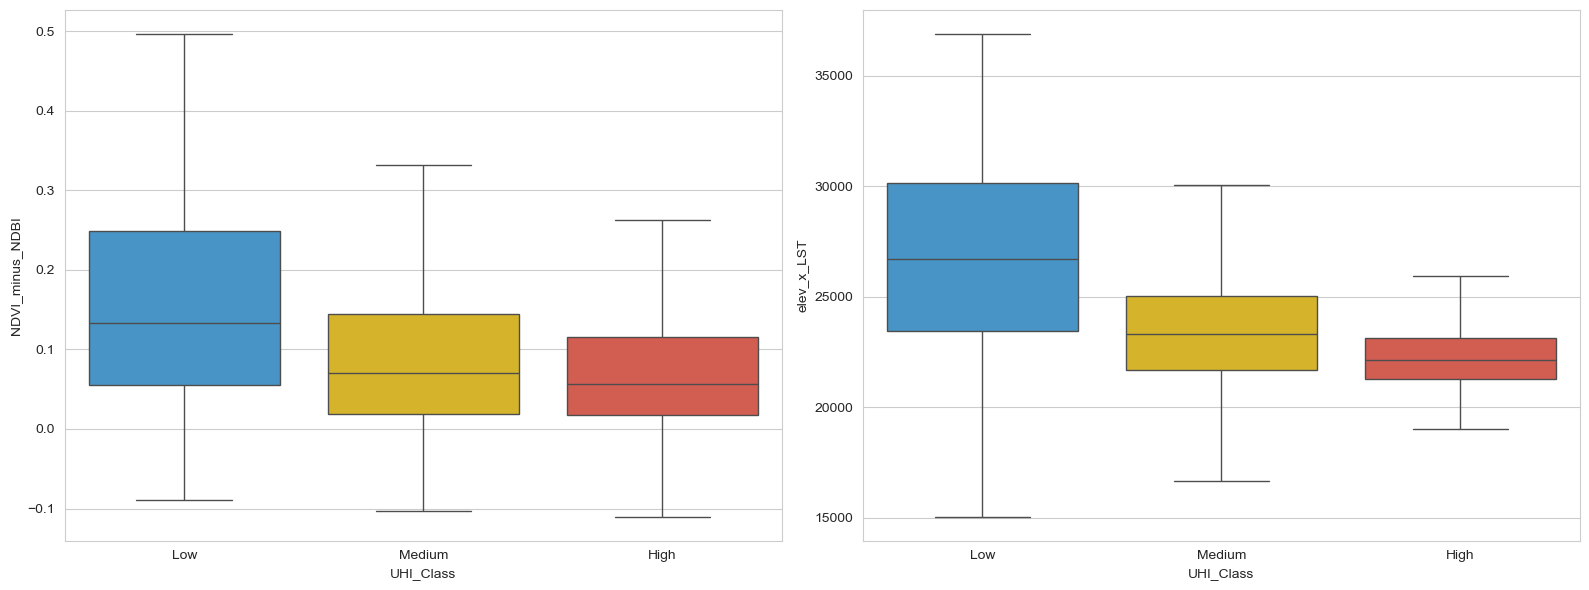

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_viz, x='UHI_Class', order=class_order, palette=class_colors, ax=ax)
ax.set_title('Chile — UHI class counts @ 100 m')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_viz, x='NDVI', y='LST', hue='UHI_Class', hue_order=class_order, palette=class_colors, alpha=0.4, edgecolor=None)
plt.title('LST vs NDVI'); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df_viz, x='UHI_Class', y='NDVI_minus_NDBI', order=class_order, palette=class_colors, ax=axes[0], showfliers=False)
sns.boxplot(data=df_viz, x='UHI_Class', y='elev_x_LST', order=class_order, palette=class_colors, ax=axes[1], showfliers=False)
plt.tight_layout(); plt.show()


### Chile — Quantile RF @ 100 m


In [25]:
X, y = prepare_xy(train_test_100)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
y_tr_enc = le.transform(y_tr); y_te_enc = le.transform(y_te)
qt_cl = QuantileTransformer(n_quantiles=min(1000, len(X_tr)), output_distribution='uniform', random_state=42)
X_tr_q = qt_cl.fit_transform(X_tr.values)
X_te_q = qt_cl.transform(X_te.values)
m1 = RandomForestClassifier(n_estimators=500, class_weight='balanced', max_depth=20,
    min_samples_split=25, max_features='sqrt', random_state=42, ccp_alpha=0.001)
m1.fit(X_tr_q, y_tr_enc)
preds_te = le.inverse_transform(m1.predict(X_te_q))
print(classification_report(y_te, preds_te))
f1_train = f1_score(y_tr_enc, m1.predict(X_tr_q), average='weighted')
f1_test = f1_score(y_te_enc, m1.predict(X_te_q), average='weighted')
print(f'F1 train={f1_train:.4f} test={f1_test:.4f} gap={f1_train-f1_test:.4f}')
feat_imp = pd.Series(m1.feature_importances_, index=X.columns).nlargest(10)
print(feat_imp)


              precision    recall  f1-score   support

        High       0.62      0.74      0.68      1064
         Low       0.70      0.67      0.69      1106
      Medium       0.72      0.67      0.69      2163

    accuracy                           0.69      4333
   macro avg       0.68      0.69      0.69      4333
weighted avg       0.69      0.69      0.69      4333

F1 train=0.7129 test=0.6878 gap=0.0251
elevation       0.204897
elev_x_LST      0.172794
lwir11          0.105571
LST             0.085157
LST_x_Albedo    0.044406
blue            0.035325
green           0.025773
red             0.021669
B01             0.018511
B12             0.017955
dtype: float64


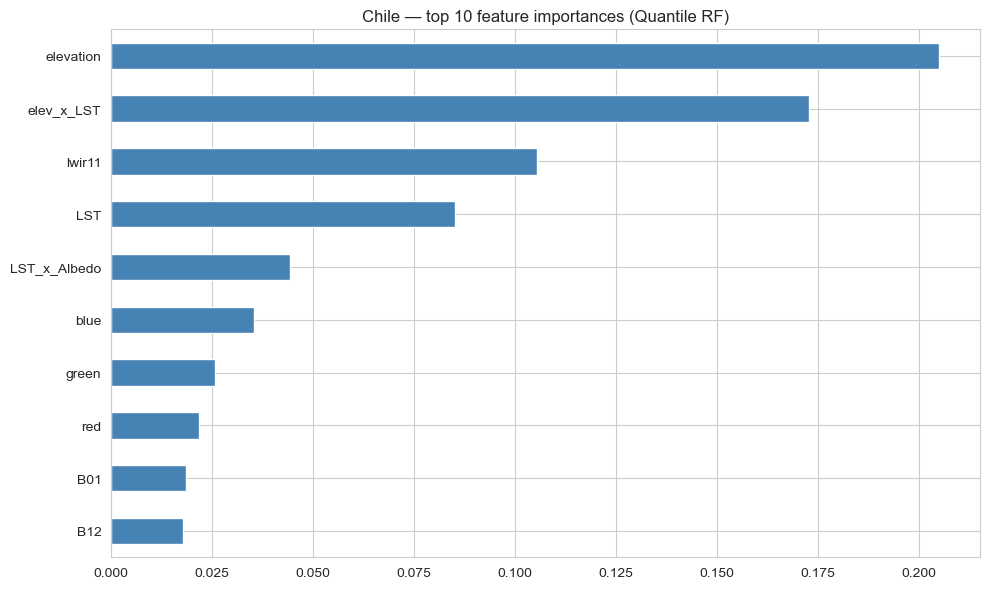

In [26]:
plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Chile — top 10 feature importances (Quantile RF)'); plt.tight_layout(); plt.show()


### Chile — interpretation

A **constrained RF** (e.g. `max_depth` capped, `min_samples_split`, `ccp_alpha`) often balances **Medium** better than an unconstrained booster on this distribution. **Elevation-heavy** models **do not** generalize geographic structure to Sierra Leone; the cross-city block deliberately avoids that feature set.


---
## Part 3 — Sierra Leone: cross-city transfer

### Domain shift & why raw scales fail

The central challenge is **domain shift**: climate, altitude, and urban form differ. **Absolute LST** ranges barely overlap between cities (e.g. Chile’s High can sit near Brazil’s Low in °C). Models trained on raw thermal thresholds **do not** transfer; **quantile normalization** removes absolute scale while preserving **within-city** ordering.

### Preprocessing strategy (Sierra Leone)

Empirical search showed **only five core bands** (`lwir11`, `LST`, `SWIR2_NIR`, `blue`, `nir08`) sustain transfer; extra indices and building metrics often **add city-specific noise**. Pipeline: **(1)** independent **QuantileTransformer** per city → **(2)** **PCA(3)** fit on labelled training features, applied to SL after QT. Independent QT per domain is the key: same shape **[0,1]**, different cities, before PCA.

### Pseudo-labels vs blind tests

**KMeans** pseudo-labels on SL (clusters mapped by mean LST) are useful for **comparing** models but can **disagree** with competition labels: clustering follows **spectral similarity**, not necessarily the same rules as human labels. **Specialist routing** (High → Brazil, Medium → Chile, Low → combined) should be validated against **held-out / competition** truth when available, not only pseudo-metrics.

### Source-specialist OVR (conceptual)

Train **binary** classifiers per UHI class, each from the **source** that transfers best for that class, then combine scores (RF + XGB optional ensemble) and **calibrate** score offsets to match an expected **class prevalence** (`SL_KNOWN`).

**Reported blind-test benchmarks (study; not recomputed here):** Brazil strongest on **High** (F1 ≈ 0.66, recall ≈ 0.69); Chile on **Medium** (F1 ≈ 0.46); **combined** Chile+Brazil on **Low** (F1 ≈ 0.61). Baselines without specialist routing were weaker (e.g. Brazil-only ~F1 0.53 with Medium ~0.38; pooled multiclass without domain adaptation ~0.48).

**Execution below:** cleaned copies `chile_c` / `brazil_c` / `df_sl` so Parts 1–2 never mutate shared `dfs`.


In [27]:
chile_c = dfs['Chile'].dropna(subset=RAW).copy()
brazil_c = dfs['Brazil'].dropna(subset=RAW).copy()
df_sl = dfs['Sierra_Leone'].copy()
for f in RAW:
    if f in df_sl.columns:
        df_sl[f] = df_sl[f].fillna(df_sl[f].median())
print(f'After cleaning — Chile={len(chile_c):,} Brazil={len(brazil_c):,} SL={len(df_sl):,}')


After cleaning — Chile=21,662 Brazil=28,488 SL=14,105


### Cross-city EDA: LST overlap, five bands, redundancy

Chile’s class mix is often **Medium-heavy**; Brazil may skew **High**. Critically, **absolute LST** can place one city’s High **below** another’s Low — so **raw** thermal features are unsafe for transfer; the plots below motivate **quantile + PCA**.

The **five transfer bands** each capture a distinct physical cue: **lwir11** raw thermal radiance; **LST** emissivity-corrected surface temperature; **SWIR2_NIR** moisture / impervious fraction; **blue** albedo / brightness; **nir08** vegetation. Together they span the thermal–urban–vegetation gradient while staying low-dimensional enough for **PCA(3)** (~most variance).

Optional **index correlation** heatmaps (NDVI, NDBI, …) illustrate redundancy: many indices are **linearly related** to base bands; that is why Part 3 restricts to **`SPEC`**.


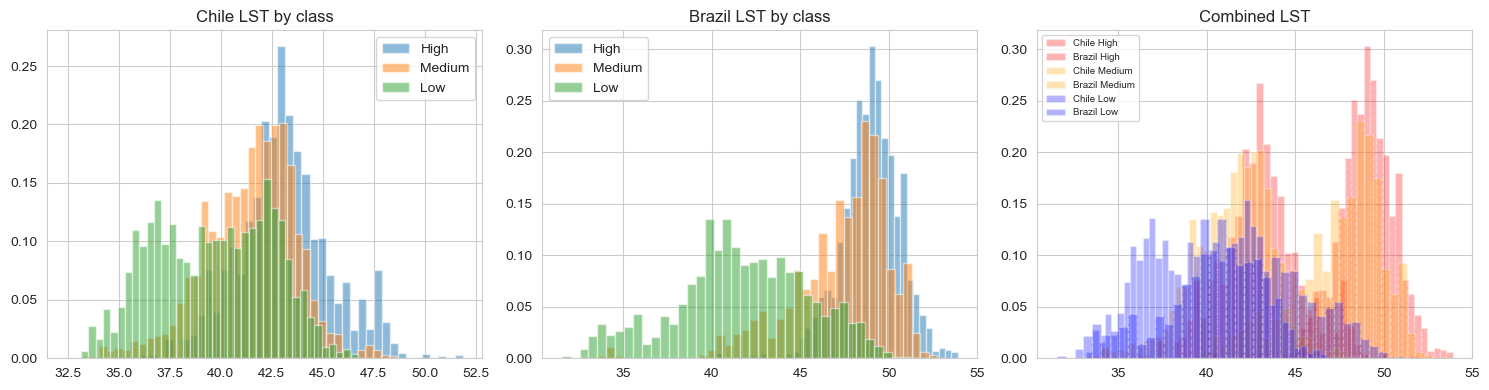

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name, dfc in zip(axes, ['Chile', 'Brazil'], [chile_c, brazil_c]):
    for cls in ['High', 'Medium', 'Low']:
        sub = dfc[dfc['UHI_Class'] == cls]['LST']
        ax.hist(sub, bins=40, alpha=0.5, label=cls, density=True)
    ax.set_title(f'{name} LST by class'); ax.legend()
for cls_col, cls in zip(['red', 'orange', 'blue'], ['High', 'Medium', 'Low']):
    for name, dfc, ls in [('Chile', chile_c, '-'), ('Brazil', brazil_c, '--')]:
        sub = dfc[dfc['UHI_Class'] == cls]['LST']
        axes[2].hist(sub, bins=40, alpha=0.3, density=True, linestyle=ls, label=f'{name} {cls}', color=cls_col)
axes[2].set_title('Combined LST'); axes[2].legend(fontsize=7)
plt.tight_layout(); plt.show()


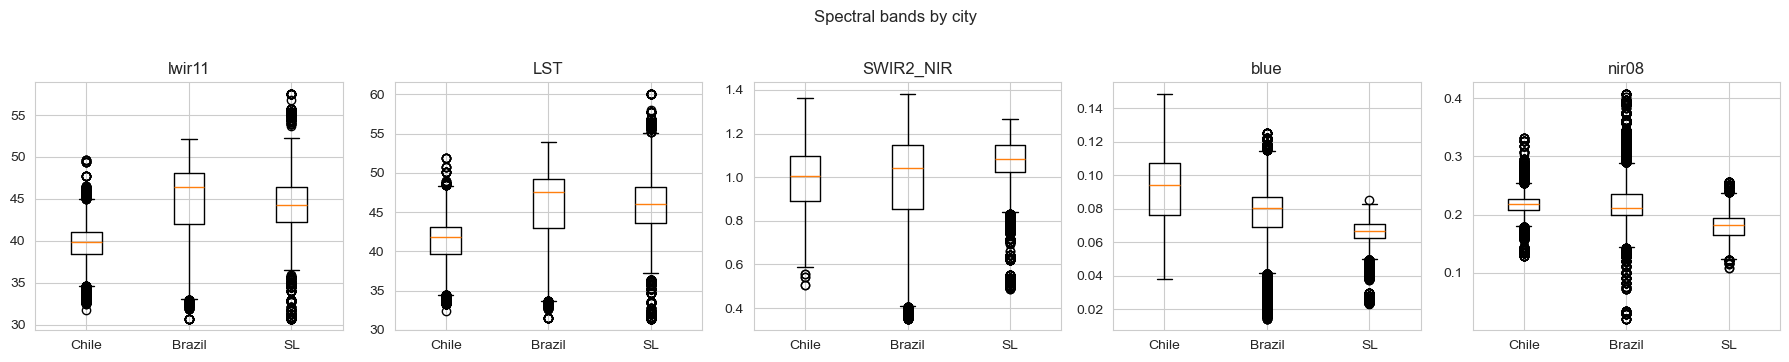

In [29]:
fig, axes = plt.subplots(1, len(SPEC), figsize=(18, 3.5))
for ax, feat in zip(axes, SPEC):
    data = [chile_c[feat].dropna(), brazil_c[feat].dropna(), df_sl[feat].dropna()]
    ax.boxplot(data, labels=['Chile', 'Brazil', 'SL'])
    ax.set_title(feat)
plt.suptitle('Spectral bands by city', y=1.02); plt.tight_layout(); plt.show()


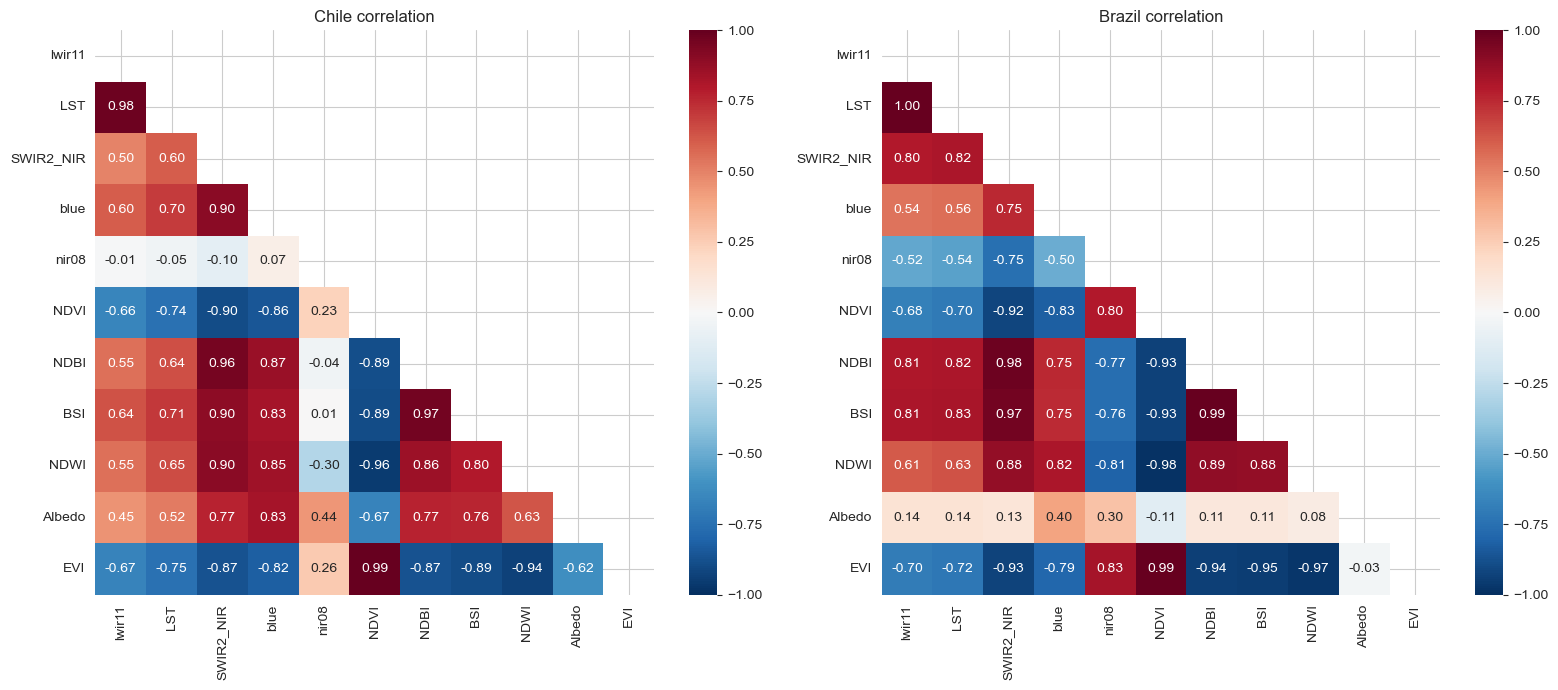

In [30]:
IDX = [c for c in ['NDVI', 'NDBI', 'BSI', 'NDWI', 'Albedo', 'EVI'] if c in chile_c.columns]
all_feats = SPEC + IDX
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, name, dfc in zip(axes, ['Chile', 'Brazil'], [chile_c, brazil_c]):
    feats = [c for c in all_feats if c in dfc.columns]
    corr = dfc[feats].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'{name} correlation')
plt.tight_layout(); plt.show()


### QT → PCA on labeled cities


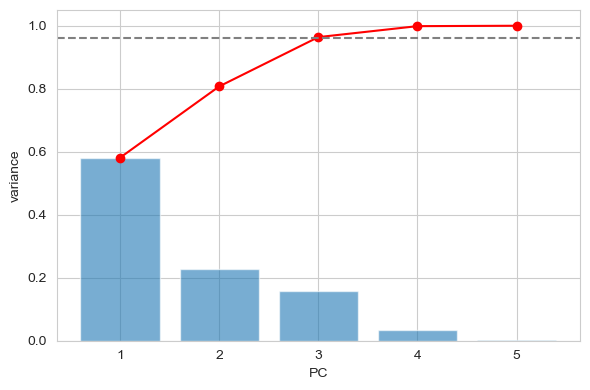

             PC0    PC1    PC2
lwir11     0.504 -0.412  0.272
LST        0.528 -0.337  0.254
SWIR2_NIR  0.508  0.346 -0.041
blue       0.292  0.772  0.225
nir08     -0.352  0.042  0.899


In [31]:
df_both = pd.concat([chile_c, brazil_c], ignore_index=True)
X_both = df_both[SPEC].fillna(0).values
qt = QuantileTransformer(n_quantiles=min(1000, len(X_both)), output_distribution='uniform', random_state=42)
X_qt = qt.fit_transform(X_both)
pca_full = PCA(random_state=42).fit(X_qt)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_, alpha=0.6)
ax.plot(range(1, len(cumvar)+1), cumvar, 'ro-')
ax.axhline(0.96, color='gray', ls='--')
ax.set_xlabel('PC'); ax.set_ylabel('variance'); plt.tight_layout(); plt.show()
pca3 = PCA(n_components=3, random_state=42).fit(X_qt)
loadings = pd.DataFrame(pca3.components_.T, index=SPEC, columns=['PC0','PC1','PC2'])
print(loadings.round(3))


### PCA interpretation (typical geometry)

On QT-transformed **five-band** stacks, **three components** often capture **~96%** of variance. **PC0** usually aligns with a **thermal–urban** axis (LST, SWIR2_NIR, lwir11 vs nir08); **PC1** may isolate **blue/albedo** variation; **PC2** often emphasizes **nir08 / vegetation** structure. Higher PCs frequently add noise for classification — hence **PCA(3)** in the transfer pipeline.


### LOCO and per-class OVR transfer


In [32]:
for src, tgt, d_src, d_tgt in [('Chile', 'Brazil', chile_c, brazil_c), ('Brazil', 'Chile', brazil_c, chile_c)]:
    X_tr, X_te, _ = qt_pca_transform(d_src[SPEC].fillna(0).values, d_tgt[SPEC].fillna(0).values)
    y_tr = le.transform(d_src['UHI_Class']); y_te = le.transform(d_tgt['UHI_Class'])
    rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    f1_tr = f1_score(y_tr, rf.predict(X_tr), average='weighted')
    f1_te = f1_score(y_te, rf.predict(X_te), average='weighted')
    print(f'{src}→{tgt}: train F1={f1_tr:.3f} test F1={f1_te:.3f} gap={f1_tr-f1_te:.3f}')

results_sl = []
for src, tgt, d_src, d_tgt in [('Chile', 'Brazil', chile_c, brazil_c), ('Brazil', 'Chile', brazil_c, chile_c)]:
    X_tr, X_te, _ = qt_pca_transform(d_src[SPEC].fillna(0).values, d_tgt[SPEC].fillna(0).values)
    y_tr = le.transform(d_src['UHI_Class']); y_te = le.transform(d_tgt['UHI_Class'])
    for cls_name in ['High', 'Medium', 'Low']:
        cls_idx = le.transform([cls_name])[0]
        y_tr_bin = (y_tr == cls_idx).astype(int); y_te_bin = (y_te == cls_idx).astype(int)
        rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr_bin)
        f1_te = f1_score(y_te_bin, rf.predict(X_te))
        results_sl.append({'source': src, 'class': cls_name, 'f1_test': f1_te})
print(pd.DataFrame(results_sl).pivot_table(index='class', columns='source', values='f1_test').round(3))


Chile→Brazil: train F1=0.742 test F1=0.468 gap=0.274
Brazil→Chile: train F1=0.901 test F1=0.360 gap=0.541
source  Brazil  Chile
class                
High     0.449  0.587
Low      0.496  0.585
Medium   0.419  0.293


### SL pseudo-labels & source → SL OVR


Freetown has no real UHI labels here, so we build a proxy with KMeans + LST ordering so we can still compare models on the same pixels.

Metrics are vs clusters, not the competition’s labels. The pseudo-target doesn’t match that definition, so high F1 can still be misleading, and train–test gap doesn’t separate overfitting from bad proxy labels like it does with real y.

Pseudo-labels can mis-rank models vs blind/competition scores; they depend on KMeans/PCA settings; they miss non-thermal criteria. Use printed F1/gap only as diagnostics.

In [33]:
df_train_sl = pd.concat([chile_c, brazil_c], ignore_index=True)
X_sl_raw = df_sl[SPEC].fillna(0).values
qt_sl = QuantileTransformer(n_quantiles=min(1000, len(X_sl_raw)), output_distribution='uniform', random_state=42)
X_sl_qt = qt_sl.fit_transform(X_sl_raw)
X_sl_pca = PCA(n_components=3, random_state=42).fit_transform(X_sl_qt)
km = KMeans(n_clusters=3, random_state=7, init='k-means++', n_init=30)
clusters = km.fit_predict(X_sl_pca)
agg = [(c, df_sl.iloc[clusters == c]['LST'].mean()) for c in range(3)]
agg.sort(key=lambda x: x[1])
cmap = {agg[0][0]: 'Low', agg[1][0]: 'Medium', agg[2][0]: 'High'}
y_sl_pseudo = np.array([cmap[c] for c in clusters])
y_sl_enc = le.transform(y_sl_pseudo)
print('Pseudo distribution:', pd.Series(y_sl_pseudo).value_counts().to_dict())


Pseudo distribution: {'Low': 5600, 'Medium': 4848, 'High': 3657}


In [34]:
sources = {'Chile': chile_c, 'Brazil': brazil_c, 'Both': df_train_sl}
sl_rows = []
for src_name, df_src in sources.items():
    X_tr, X_te, _ = qt_pca_transform(df_src[SPEC].fillna(0).values, X_sl_raw)
    y_tr = le.transform(df_src['UHI_Class'])
    for cls_name in ['High', 'Medium', 'Low']:
        cls_idx = le.transform([cls_name])[0]
        y_tr_bin = (y_tr == cls_idx).astype(int); y_te_bin = (y_sl_enc == cls_idx).astype(int)
        rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr_bin)
        prob = rf.predict_proba(X_te)[:, 1]
        y_pred = (prob > 0.5).astype(int)
        sl_rows.append({'source': src_name, 'class': cls_name,
            'f1_test': f1_score(y_te_bin, y_pred)})
print(pd.DataFrame(sl_rows).pivot_table(index='class', columns='source', values='f1_test').round(3))


source   Both  Brazil  Chile
class                       
High    0.613   0.479  0.747
Low     0.810   0.885  0.543
Medium  0.362   0.284  0.657


### Source-specialist RF / XGB, calibration, ensemble, export

Conceptual routing (validate with your blind tests):

| Class | Typical best source | Rationale (heuristic) |
|-------|---------------------|------------------------|
| **High** | Brazil | Dense tropical urban cores, thermal signature overlap with Freetown high-heat zones. |
| **Medium** | Chile | Transitional / peri-urban spectral behaviour. |
| **Low** | Chile + Brazil combined | Balanced vegetation / cool-area signal from both regimes. |

The code block below instantiates `SPECIALISTS` and runs RF → calibration → XGB → **ensemble** → saves `sierra_leone_submission.csv`.


In [35]:
SPECIALISTS = {'High': brazil_c, 'Low': df_train_sl, 'Medium': chile_c}

def train_specialist(df_src, cls_name, X_sl_r):
    X_tr_raw = df_src[SPEC].fillna(0).values
    X_tr, X_te, _ = qt_pca_transform(X_tr_raw, X_sl_r)
    y_tr = (df_src['UHI_Class'] == cls_name).astype(int).values
    rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    return rf.predict_proba(X_te)[:, 1], rf

scores = {}
for cls_name, d_src in SPECIALISTS.items():
    prob, _ = train_specialist(d_src, cls_name, X_sl_raw)
    scores[cls_name] = prob

score_matrix = np.column_stack([scores['High'], scores['Low'], scores['Medium']])
y_raw = le.classes_[np.argmax(score_matrix, axis=1)]
print('RF specialist argmax F1 vs pseudo:', round(f1_score(y_sl_pseudo, y_raw, average='weighted'), 3))


RF specialist argmax F1 vs pseudo: 0.515


In [36]:
SL_KNOWN = {'High': 5087, 'Medium': 6000, 'Low': 3018}
target_frac = {k: v/sum(SL_KNOWN.values()) for k, v in SL_KNOWN.items()}

def calibrate_offsets(score_matrix):
    def objective(offsets):
        adj = score_matrix.copy()
        for i in range(3):
            adj[:, i] += offsets[i]
        preds = le.classes_[np.argmax(adj, axis=1)]
        dist = pd.Series(preds).value_counts(normalize=True)
        return sum((dist.get(c, 0) - target_frac[c])**2 for c in target_frac)
    res = minimize(objective, [0, 0, 0], method='Nelder-Mead')
    adj = score_matrix.copy()
    for i in range(3):
        adj[:, i] += res.x[i]
    return le.classes_[np.argmax(adj, axis=1)], res.x

y_cal, offs = calibrate_offsets(score_matrix)
print('Offsets:', offs)
print('Calibrated dist:', pd.Series(y_cal).value_counts().to_dict())


Offsets: [0. 0. 0.]
Calibrated dist: {'High': 6411, 'Low': 4196, 'Medium': 3498}


In [37]:
def train_xgb_specialist(df_src, cls_name, X_sl_r):
    X_tr_raw = df_src[SPEC].fillna(0).values
    X_tr, X_te, _ = qt_pca_transform(X_tr_raw, X_sl_r)
    y_tr = (df_src['UHI_Class'] == cls_name).astype(int).values
    xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=len(y_tr[y_tr==0]) / max(len(y_tr[y_tr==1]), 1),
        random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0)
    xgb.fit(X_tr, y_tr)
    return xgb.predict_proba(X_te)[:, 1]

scores_xgb = {}
for cls_name, d_src in SPECIALISTS.items():
    scores_xgb[cls_name] = train_xgb_specialist(d_src, cls_name, X_sl_raw)

score_matrix_xgb = np.column_stack([scores_xgb['High'], scores_xgb['Low'], scores_xgb['Medium']])
y_cal_xgb, _ = calibrate_offsets(score_matrix_xgb)
print('XGB calibrated F1 vs pseudo:', round(f1_score(y_sl_pseudo, y_cal_xgb, average='weighted'), 3))


XGB calibrated F1 vs pseudo: 0.505


In [39]:
score_ensemble = (score_matrix + score_matrix_xgb) / 2
y_cal_ens, _ = calibrate_offsets(score_ensemble)
print('Ensemble calibrated F1 vs pseudo:', round(f1_score(y_sl_pseudo, y_cal_ens, average='weighted'), 3))
print('Compare RF:', round(f1_score(y_sl_pseudo, y_cal, average='weighted'), 3),
      'XGB:', round(f1_score(y_sl_pseudo, y_cal_xgb, average='weighted'), 3),
      'Ens:', round(f1_score(y_sl_pseudo, y_cal_ens, average='weighted'), 3))


Ensemble calibrated F1 vs pseudo: 0.518
Compare RF: 0.515 XGB: 0.505 Ens: 0.518


In [40]:
y_final = y_cal_ens  # switch to y_cal or y_cal_xgb if preferred
sub = pd.DataFrame({'Longitude': df_sl['Longitude'], 'Latitude': df_sl['Latitude'], 'UHI_Class': y_final})
sl_path = os.path.join(OUTPUT_DIR, 'sierra_leone_submission.csv')
sub.to_csv(sl_path, index=False)
print('Saved', sl_path, 'rows:', len(sub))
sub.head()


Saved ./sierra_leone_submission.csv rows: 14105


,Longitude,Latitude,UHI_Class
0,-13.272932,8.447807,Medium
1,-13.272938,8.447757,Medium
2,-13.272997,8.447133,Medium
3,-13.273002,8.447015,Medium
4,-13.273007,8.446915,Medium


## Challenge reflection (from Answers.docx)

- **Value:** Working with **satellite-derived** features builds skills beyond flat tables — interpretation, feature choice, and **transfer** matter more than raw column count.
- **Core insight:** **Cross-city** performance tests whether the model learns **heat structure** vs **city-specific artefacts**.
- **Possible extensions (not implemented here):** **Regression** on continuous thermal indices (not only classes); **aligned label collection** (consistent time-of-day, repeated readings) to limit **temporal noise**; richer **time-series** and **multi-resolution** tests when open data allow. See also [US EPA — measuring heat islands](https://www.epa.gov/heatislands/measuring-heat-islands).


## References (from report; selection)

- American Physiological Society (2016). *In Santiago, What’s Smog Got to Do with It?* https://ispyphysiology.com/2016/08/10/in-santiago-whats-smog-got-to-do-with-it/
- Edson et al. (2009). *Rio de Janeiro’s Tropical Urban Climate.* https://www.researchgate.net/publication/275212388_Rio_de_Janeiro
- Eromo Egbejule / The Guardian (2024). *Mirror roofs cooling homes in Freetown.* https://www.theguardian.com/environment/article/2024/aug/16/mirror-roofs-cooling-homes-freetown-sierra-leone-extreme-heat
- João Cortesão et al. (2023). *Cooling urban water environments.* https://doi.org/10.1080/13574809.2023.2240248
- Lee & Kim (2022). *Urban heating problem and mitigation framework.* https://doi.org/10.3390/ijerph191610249
- Miranda et al. (2022). *Urbanization impacts on heat fluxes — Rio.* https://doi.org/10.1016/j.buildenv.2022.109008
- Mohajerani et al. (2017). *UHI causes and mitigation / asphalt properties.* https://doi.org/10.1016/j.jenvman.2017.03.095
- NASA Earth Observatory (2017). *Climate Proofing Rio de Janeiro.* https://science.nasa.gov/earth/earth-observatory/climate-proofing-rio-de-janeiro-90687/
- Peres et al. (2018). *UHI in Rio — remote sensing.* https://doi.org/10.1016/j.jag.2017.08.012
- Reckford & Aki-Sawyerr (2023). *Informal settlements — WEF.* https://www.weforum.org/stories/2023/08/informal-settlements-are-growing-heres-how-we-provide-everyone-a/
- Schneider et al. (2023). *Reflective pavement for urban heat.* https://doi.org/10.1038/s41467-023-36972-5
- Sen & Khazanovich (2021). *Reflective surfaces mitigate urban heat.* https://doi.org/10.1038/s41467-021-23634-7
- Wallace (2023). *Santiago — local heat resilience.* https://onebillionresilient.org/2023/04/27/how-santiago-is-building-heat-resilience/
- US EPA (2014). *Measuring Heat Islands.* https://www.epa.gov/heatislands/measuring-heat-islands


---
## Summary

**One notebook, three regimes.** **Within-city** models (Parts 1–2) use **rich features** and strong QT/RF/XGB where train and test share a city. **Cross-city** Sierra Leone (Part 3) **strips** to **five bands**, uses **independent QT**, **PCA(3)**, and **source-specialist** OVR with **score calibration** to match approximate prevalence.

**Lesson:** internal metrics on **KMeans pseudo-labels** can rank sources differently than **blind tests** against real competition labels — prioritize external validation for routing decisions.

**Source parity:** Part 1 aligns with `Brazil_Within_City_Model.ipynb`; Part 2 with `Chile.ipynb` @ 100 m; Part 3 with `SL_Class_based_Pipeline.ipynb`. This file adds **GitHub-based loading**, **merged buildings** for Brazil, **written-report sections** (introduction, Q1–Q3, pipeline mapping, reflection, references), and a **single-path** narrative.
